<a href="https://colab.research.google.com/github/anshpatel-177/-PREDICTIVE-ANALYTICS-USING-HISTORICAL-DATA-/blob/main/PREDICTIVE_ANALYTICS_USING_HISTORICAL_DATA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# PREDICTIVE ANALYTICS USING HISTORICAL DATA
# Sales Prediction using Linear Regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
df = pd.read_csv("/content/sales_data.csv")
df.head()
df.info()
# Data Cleaning
df.isnull().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    180 non-null    object 
 1   Sales   180 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.9+ KB


np.int64(0)

In [3]:
# Remove duplicate rows
df = df.drop_duplicates()

In [6]:
# Remove missing values
df = df.dropna()

# Convert Date Column

df['Date'] = pd.to_datetime(df['Date'])

# Sort data according to date
df = df.sort_values('Date')
df

,Date,Sales
0,2025-01-01,122.74
1,2025-01-02,120.52
2,2025-01-03,139.46
3,2025-01-04,135.18
4,2025-01-05,99.25
...,...,...
175,2025-06-25,209.54
176,2025-06-26,232.09
177,2025-06-27,222.13
178,2025-06-28,213.64



Cleaned Dataset:
        Date   Sales  Year  Month  Day
0 2025-01-01  122.74  2025      1    1
1 2025-01-02  120.52  2025      1    2
2 2025-01-03  139.46  2025      1    3
3 2025-01-04  135.18  2025      1    4
4 2025-01-05   99.25  2025      1    5


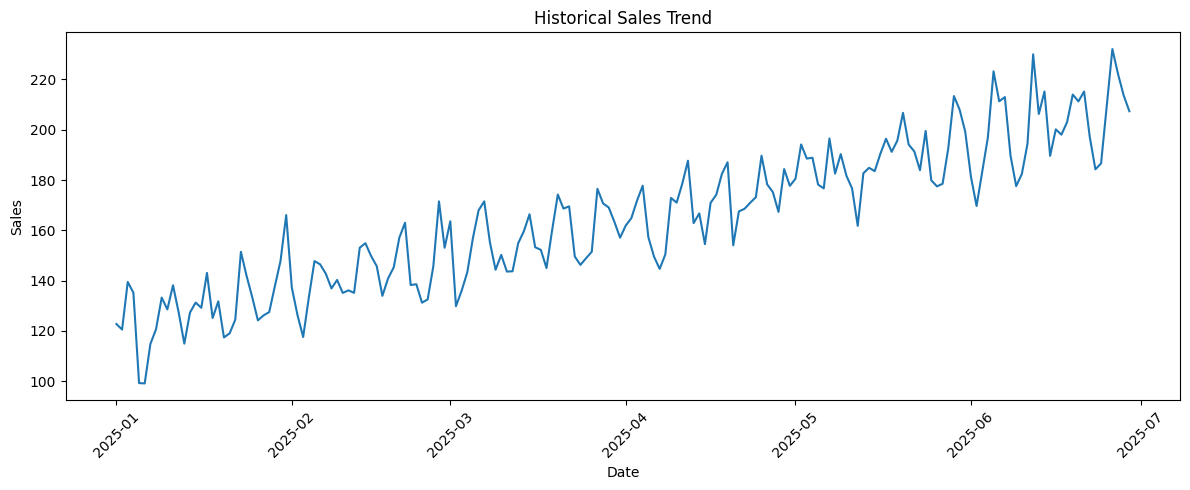

In [7]:
# Create date-based features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

print("\nCleaned Dataset:")
print(df.head())

# Visualize Historical Sales

plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Sales'])

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Historical Sales Trend")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

X = df[['Year', 'Month', 'Day']]
y = df['Sales']


In [9]:
# Split Data into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (144, 3)
Testing Data: (36, 3)


In [10]:
#  Create and Train Model
model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Training Completed!")



Model Training Completed!


In [11]:
y_pred = model.predict(X_test)

# Model Evaluation

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL EVALUATION ==========")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)



========== MODEL EVALUATION ==========
Mean Absolute Error (MAE): 11.389433459692551
Mean Squared Error (MSE): 188.9943578285374
Root Mean Squared Error (RMSE): 13.74752187954387
R2 Score: 0.6842902621464678



Actual vs Predicted Sales:
   Actual Sales  Predicted Sales
0        117.40       128.762577
1        135.13       140.047605
2        183.17       197.136319
3        174.23       159.644702
4        177.47       193.643854
5        129.19       126.684559
6        133.42       131.360098
7        150.21       154.449660
8        173.18       177.163782
9        184.36       179.761304


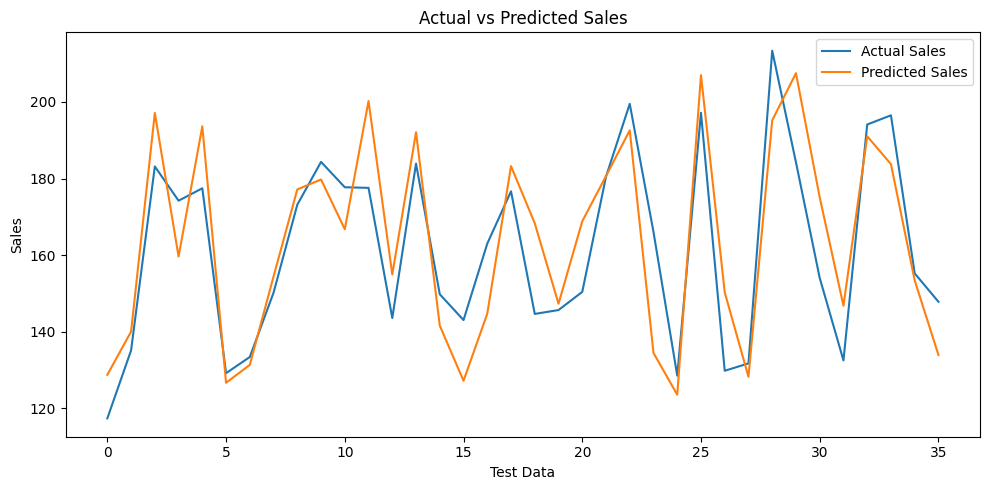

In [12]:
#  Actual vs Predicted Values
comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

print("\nActual vs Predicted Sales:")
print(comparison.head(10))

# Actual vs Predicted Visualization
plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values,
    label='Actual Sales'
)

plt.plot(
    y_pred,
    label='Predicted Sales'
)

plt.xlabel("Test Data")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
#Predict Future Sales
last_date = df['Date'].max()

# Predict next 5 days
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=5
)

future_data = pd.DataFrame({
    'Date': future_dates
})

# Create features for future dates
future_data['Year'] = future_data['Date'].dt.year
future_data['Month'] = future_data['Date'].dt.month
future_data['Day'] = future_data['Date'].dt.day

# Select features
future_X = future_data[['Year', 'Month', 'Day']]

# Predict future sales
future_predictions = model.predict(future_X)

future_data['Predicted Sales'] = future_predictions

print("\n========== FUTURE SALES PREDICTION ==========")
print(future_data)



========== FUTURE SALES PREDICTION ==========
        Date  Year  Month  Day  Predicted Sales
0 2025-06-30  2025      6   30       211.162934
1 2025-07-01  2025      7    1       211.538373
2 2025-07-02  2025      7    2       212.057878
3 2025-07-03  2025      7    3       212.577382
4 2025-07-04  2025      7    4       213.096886


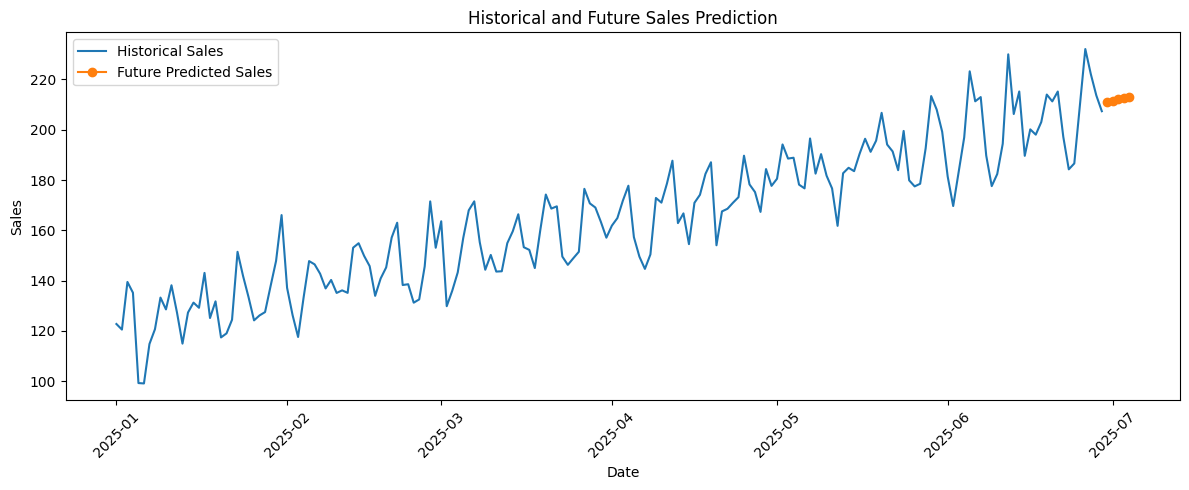

In [14]:
# Visualize Historical + Future Sales

plt.figure(figsize=(12, 5))

# Historical sales
plt.plot(
    df['Date'],
    df['Sales'],
    label='Historical Sales'
)

# Future predictions
plt.plot(
    future_data['Date'],
    future_data['Predicted Sales'],
    marker='o',
    label='Future Predicted Sales'
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Historical and Future Sales Prediction")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
print("\n========== PROJECT COMPLETED ==========")
print("Predictive Analytics model successfully created.")
print("Historical sales were analyzed.")
print("Linear Regression model was trained.")
print("Model accuracy was evaluated.")
print("Future sales were predicted.")


========== PROJECT COMPLETED ==========
Predictive Analytics model successfully created.
Historical sales were analyzed.
Linear Regression model was trained.
Model accuracy was evaluated.
Future sales were predicted.
